# CSIS3764 Semester Test 2 - Question 2
# Student Number: 2024679777

## Import required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

## 2.1 Import the data file into a dataframe named "dfcus"  

In [20]:
dfcus = pd.read_csv('bank_customers.csv')
print("Original dataset shape:", dfcus.shape)
print(dfcus.head())

Original dataset shape: (10127, 23)
   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     R60K - R80K          Blue   
1        Graduate         Single  Less than R40K          Blue   
2        Graduate        Married    R80K - R120K          Blue   
3     High School        Unknown  Less than R40K          Blue   
4      Uneducated        Married     R60K - R80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691.0              

## 2.2 Inspect the data

In [21]:
# Generate concise summary
print("\nData Summary:")
print(dfcus.info())

# Display unique values for each feature
print("\nUnique values for each feature:")
for col in dfcus.columns:
    print(f"{col}: {dfcus[col].nunique()} unique values")


Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  floa

## 2.3 Discard the first and last 7 columns

In [22]:
dfcus = dfcus.iloc[:, 1:-7]
print("\nDataset after removing first and last 7 columns:")
print(dfcus.shape)
print(dfcus.head())


Dataset after removing first and last 7 columns:
(10127, 15)
      Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
0  Existing Customer            45      M                3     High School   
1  Existing Customer            49      F                5        Graduate   
2  Existing Customer            51      M                3        Graduate   
3  Existing Customer            40      F                4     High School   
4  Existing Customer            40      M                3      Uneducated   

  Marital_Status Income_Category Card_Category  Months_on_book  \
0        Married     R60K - R80K          Blue              39   
1         Single  Less than R40K          Blue              44   
2        Married    R80K - R120K          Blue              36   
3        Unknown  Less than R40K          Blue              34   
4        Married     R60K - R80K          Blue              21   

   Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_m

## 2.4 Generate statistical summary

In [23]:
print("\nStatistical Summary:")
print(dfcus.describe(include='all'))


Statistical Summary:
           Attrition_Flag  Customer_Age Gender  Dependent_count  \
count               10127  10127.000000  10127     10127.000000   
unique                  2           NaN      2              NaN   
top     Existing Customer           NaN      F              NaN   
freq                 8500           NaN   5358              NaN   
mean                  NaN     46.325960    NaN         2.346203   
std                   NaN      8.016814    NaN         1.298908   
min                   NaN     26.000000    NaN         0.000000   
25%                   NaN     41.000000    NaN         1.000000   
50%                   NaN     46.000000    NaN         2.000000   
75%                   NaN     52.000000    NaN         3.000000   
max                   NaN     73.000000    NaN         5.000000   

       Education_Level Marital_Status Income_Category Card_Category  \
count            10127          10127           10127         10127   
unique               7         

## 2.4.1 What can be deduced from the statistical summary with regard to the customers' marital status?

In [24]:
marital_status_counts = dfcus['Marital_Status'].value_counts()
print("\nDeduction about marital status:")
print(f"The majority of customers are married. Out of {dfcus.shape[0]} customers, {marital_status_counts.iloc[0]} are married, which represents {(marital_status_counts.iloc[0]/dfcus.shape[0]*100):.1f}% of the dataset.")


Deduction about marital status:
The majority of customers are married. Out of 10127 customers, 4687 are married, which represents 46.3% of the dataset.


## 2.5 Visualize the data using seaborn

<Figure size 1200x800 with 0 Axes>

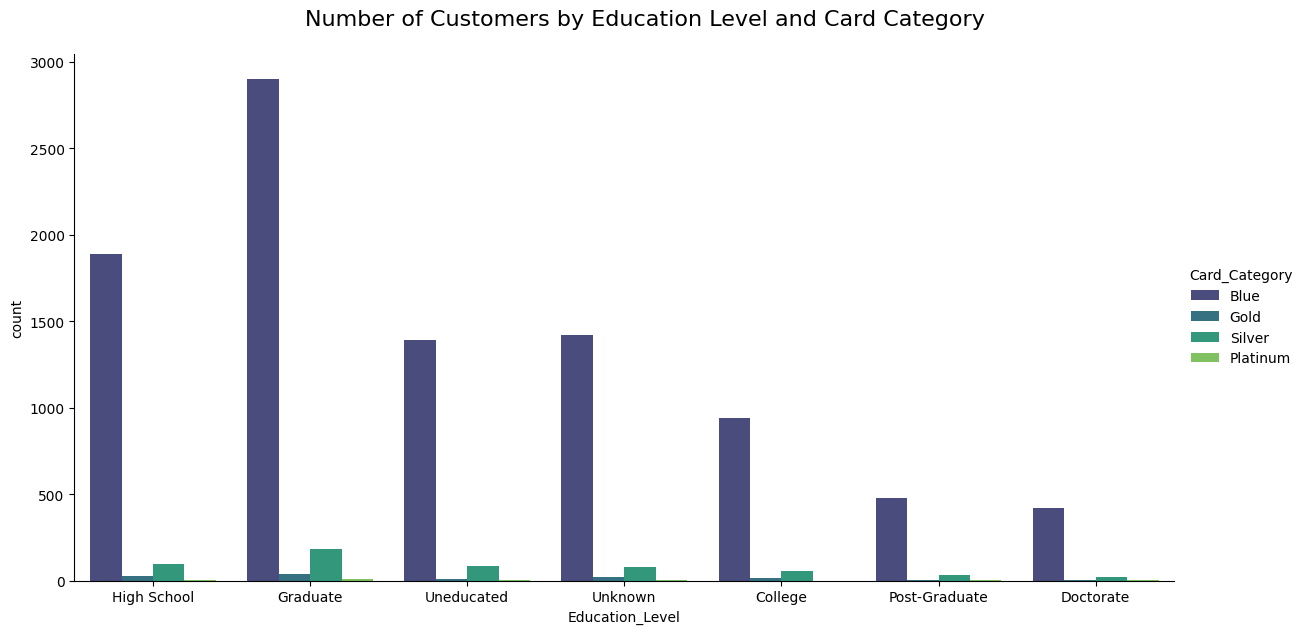


Observation from the categorical plot:
The plot shows that Graduate education level has the highest number of customers across all card categories. The Blue card type is the most common across all education levels, followed by Silver, Gold, and Platinum being the least common. This suggests that the bank's customer base is predominantly well-educated, and the basic Blue card is the most issued card type regardless of education level.


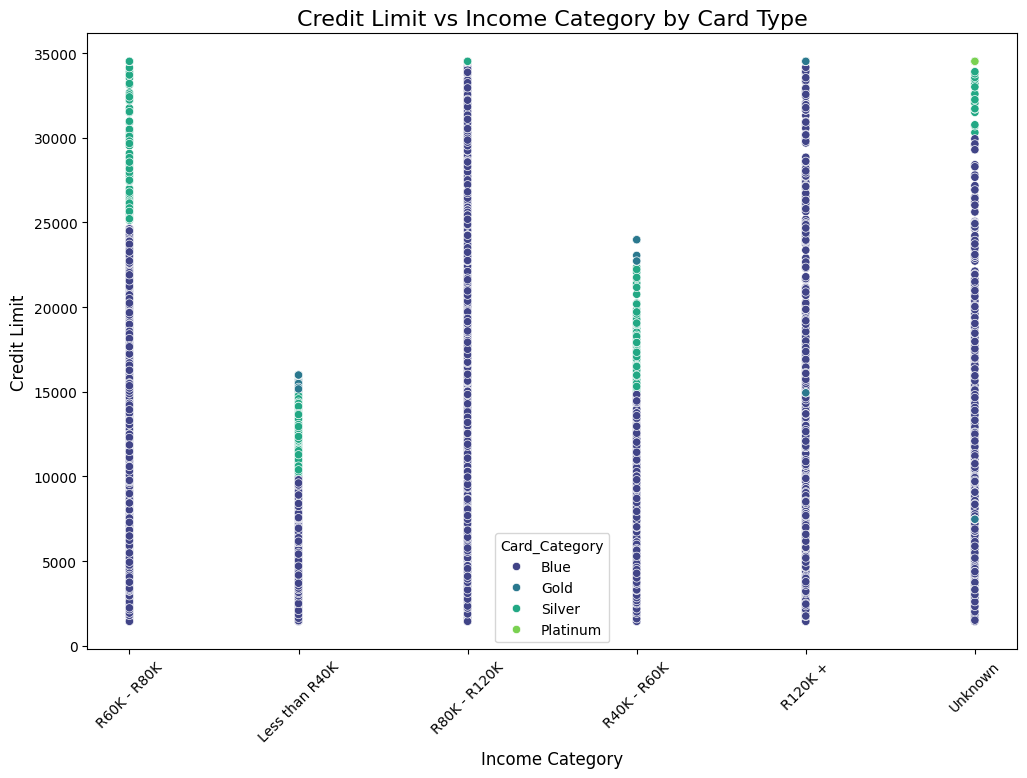


Observation from the scatter plot:
The scatter plot reveals a positive correlation between income category and credit limit. Customers with higher income categories tend to have higher credit limits. Additionally, the card category also influences the credit limit, with Platinum cardholders having the highest credit limits, followed by Gold, Silver, and Blue. This shows the bank's credit limit policies are influenced by both income level and card type.


In [25]:
plt.figure(figsize=(12, 8))
catplot = sns.catplot(data=dfcus, x='Education_Level', hue='Card_Category', kind='count', palette='viridis', height=6, aspect=2)
catplot.fig.suptitle('Number of Customers by Education Level and Card Category', y=1.05, fontsize=16)
plt.savefig('catplot.png')
plt.show()

print("\nObservation from the categorical plot:")
print("The plot shows that Graduate education level has the highest number of customers across all card categories. The Blue card type is the most common across all education levels, followed by Silver, Gold, and Platinum being the least common. This suggests that the bank's customer base is predominantly well-educated, and the basic Blue card is the most issued card type regardless of education level.")

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=dfcus, x='Income_Category', y='Credit_Limit', hue='Card_Category', palette='viridis')
plt.title('Credit Limit vs Income Category by Card Type', fontsize=16)
plt.xlabel('Income Category', fontsize=12)
plt.ylabel('Credit Limit', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('scatterplot.png')
plt.show()

print("\nObservation from the scatter plot:")
print("The scatter plot reveals a positive correlation between income category and credit limit. Customers with higher income categories tend to have higher credit limits. Additionally, the card category also influences the credit limit, with Platinum cardholders having the highest credit limits, followed by Gold, Silver, and Blue. This shows the bank's credit limit policies are influenced by both income level and card type.")

## 2.6 Determine data balance with regard to Attrition_Flag

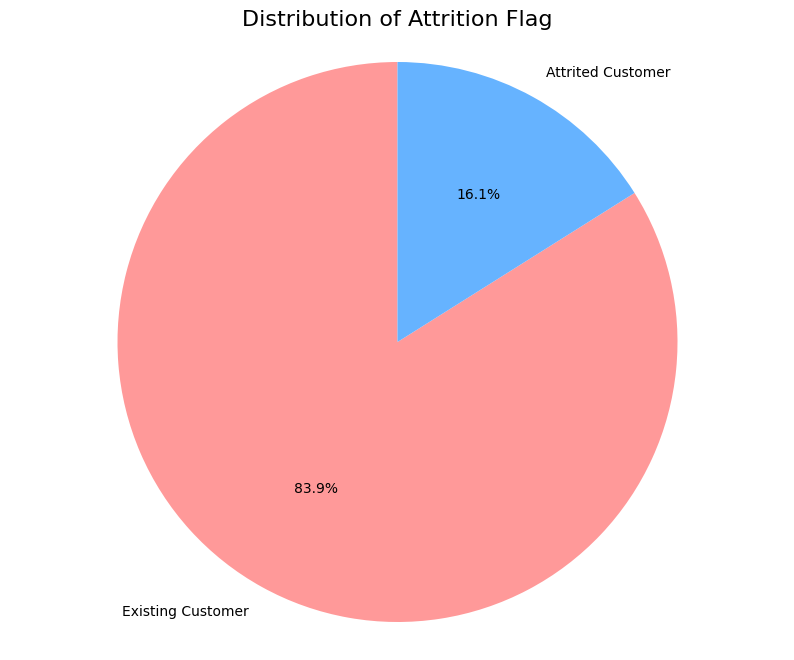


Data Balance:
Existing Customers: 8500 (83.9%)
Attrited Customers: 1627 (16.1%)
The data is imbalanced, with a significantly higher percentage of existing customers compared to attrited customers.


In [26]:
plt.figure(figsize=(10, 8))
attrition_counts = dfcus['Attrition_Flag'].value_counts(normalize=True) * 100
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Attrition Flag', fontsize=16)
plt.axis('equal')
plt.savefig('pie_chart.png')
plt.show()

print("\nData Balance:")
print(f"Existing Customers: {dfcus['Attrition_Flag'].value_counts()['Existing Customer']} ({attrition_counts['Existing Customer']:.1f}%)")
print(f"Attrited Customers: {dfcus['Attrition_Flag'].value_counts()['Attrited Customer']} ({attrition_counts['Attrited Customer']:.1f}%)")
print("The data is imbalanced, with a significantly higher percentage of existing customers compared to attrited customers.")

## 2.7 Balance the data using undersampling


Resampled dataset shape: (3254, 15)

Resampled Attrition Flag distribution:
Attrition_Flag
Attrited Customer    1627
Existing Customer    1627
Name: count, dtype: int64


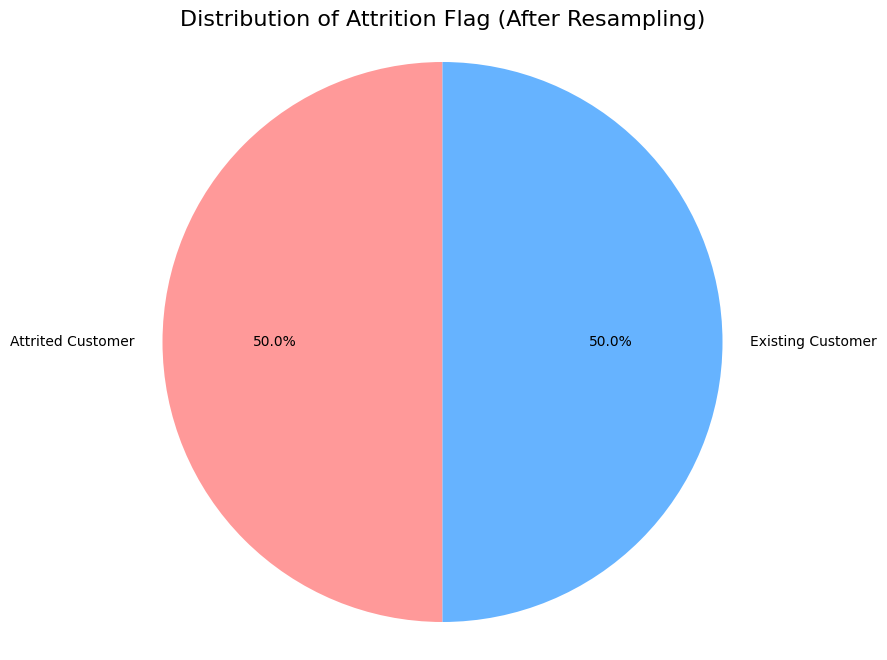

In [27]:
X = dfcus.drop('Attrition_Flag', axis=1)
y = dfcus['Attrition_Flag']

# Undersample the majority class to match the minority class
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Create a balanced dataframe
dfcus_resampled = pd.DataFrame(X_resampled, columns=X.columns)
dfcus_resampled['Attrition_Flag'] = y_resampled

print("\nResampled dataset shape:", dfcus_resampled.shape)
print("\nResampled Attrition Flag distribution:")
print(dfcus_resampled['Attrition_Flag'].value_counts())

# Verify balance with a pie chart
plt.figure(figsize=(10, 8))
resampled_counts = dfcus_resampled['Attrition_Flag'].value_counts(normalize=True) * 100
plt.pie(resampled_counts, labels=resampled_counts.index, autopct='%.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of Attrition Flag (After Resampling)', fontsize=16)
plt.axis('equal')
plt.savefig('resampled_pie_chart.png')
plt.show()

## 2.8 Convert text values to numeric values

In [28]:
# First, make a copy of the resampled dataframe
dfcus_encoded = dfcus_resampled.copy()

# Identify columns with text values
categorical_cols = dfcus_encoded.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:", categorical_cols)

# Convert binary categorical columns to 0/1
binary_cols = []
multi_value_cols = []

for col in categorical_cols:
    if dfcus_encoded[col].nunique() == 2:
        binary_cols.append(col)
    elif dfcus_encoded[col].nunique() > 2:
        multi_value_cols.append(col)

# Apply binary encoding (0/1)
for col in binary_cols:
    le = LabelEncoder()
    dfcus_encoded[col] = le.fit_transform(dfcus_encoded[col])
    print(f"\nBinary encoding for {col}:")
    for i, class_name in enumerate(le.classes_):
        print(f"{class_name} -> {i}")

# Apply one-hot encoding for multi-value columns
dfcus_encoded = pd.get_dummies(dfcus_encoded, columns=multi_value_cols, drop_first=False)

print("\nDataframe after encoding:")
print(dfcus_encoded.head())
print(dfcus_encoded.shape)


Categorical columns: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Attrition_Flag']

Binary encoding for Gender:
F -> 0
M -> 1

Binary encoding for Attrition_Flag:
Attrited Customer -> 0
Existing Customer -> 1

Dataframe after encoding:
    Customer_Age  Gender  Dependent_count  Months_on_book  \
21            62       0                0              49   
39            66       0                0              56   
51            54       0                1              40   
54            56       1                2              36   
61            48       1                2              35   

    Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_mon  \
21                         2                       3                      3   
39                         5                       4                      3   
51                         2                       3                      1   
54                         1            

## 2.9 Define X and y and create training/testing datasets

In [29]:
X = dfcus_encoded.drop('Attrition_Flag', axis=1)
y = dfcus_encoded['Attrition_Flag']

# Split data into training and testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nDimensions of datasets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Dimensions of datasets:
X_train shape: (2603, 31)
X_test shape: (651, 31)
y_train shape: (2603,)
y_test shape: (651,)


## 2.10 Train classifiers and determine the best model using k-fold cross-validation


Cross-validation results:

Naive Bayes:
  Cross-validated training accuracy: 0.7127 (±0.0227)
  Cross-validated F1 score: 0.7216 (±0.0230)

Support Vector Machine:
  Cross-validated training accuracy: 0.5509 (±0.0125)
  Cross-validated F1 score: 0.6819 (±0.0097)

Generating learning curves...


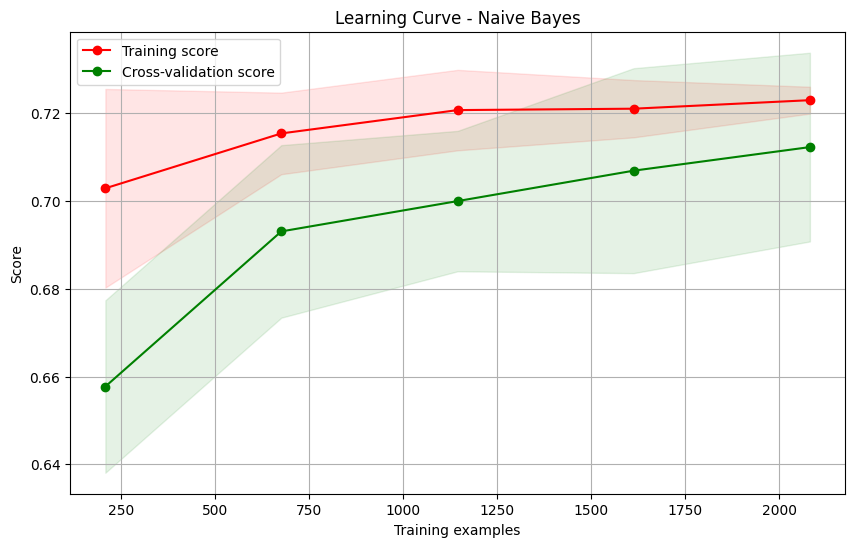

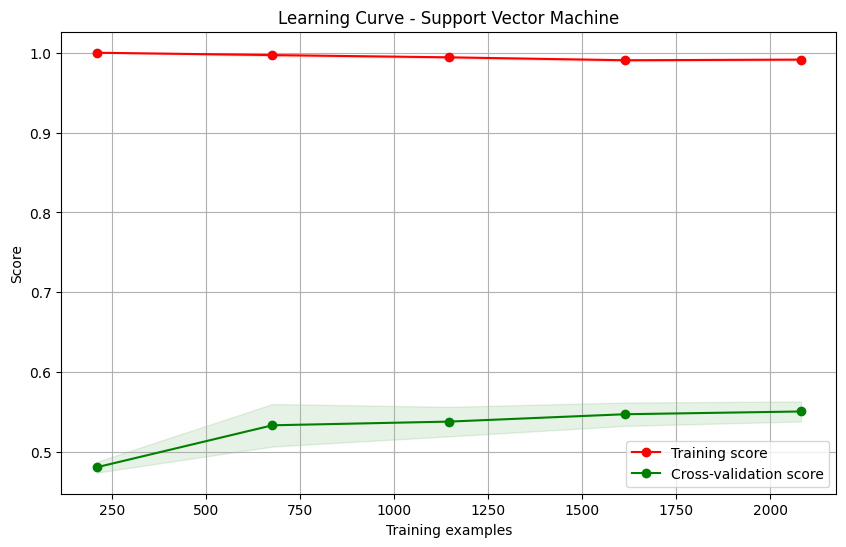


Best model based on F1 score: Naive Bayes with F1 score of 0.7216


In [30]:
# Define classifiers
classifiers = {
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(gamma='auto')
}

# Set k = 5 for k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# For storing results
cv_accuracy_scores = {}
cv_f1_scores = {}

# Perform cross-validation for each classifier
print("\nCross-validation results:")
for name, clf in classifiers.items():
    # Calculate cross-validated accuracy and F1 scores
    cv_accuracy = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')
    cv_f1 = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1')
    
    cv_accuracy_scores[name] = cv_accuracy.mean()
    cv_f1_scores[name] = cv_f1.mean()
    
    print(f"\n{name}:")
    print(f"  Cross-validated training accuracy: {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})")
    print(f"  Cross-validated F1 score: {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")

# Generate learning curves for each classifier
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, return_times=False)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    
    return plt

print("\nGenerating learning curves...")
for name, clf in classifiers.items():
    plot_learning_curve(clf, f'Learning Curve - {name}', X_train, y_train, cv=kf)
    plt.savefig(f'learning_curve_{name.replace(" ", "_").lower()}.png')
    plt.show()

# Find the best model based on F1 score
best_model_name = max(cv_f1_scores, key=cv_f1_scores.get)
best_model = classifiers[best_model_name]
print(f"\nBest model based on F1 score: {best_model_name} with F1 score of {cv_f1_scores[best_model_name]:.4f}")

## 2.11 Select the model with highest F1 score for final evaluation

In [31]:
# Train the best model
best_model.fit(X_train, y_train)

# Make predictions using the test dataset
y_pred = best_model.predict(X_test)

# Provide evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nFinal evaluation of {best_model_name}:")
print(f"Test accuracy score: {test_accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Final evaluation of Naive Bayes:
Test accuracy score: 0.7296

Confusion Matrix:
[[243 106]
 [ 70 232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.70      0.73       349
           1       0.69      0.77      0.72       302

    accuracy                           0.73       651
   macro avg       0.73      0.73      0.73       651
weighted avg       0.73      0.73      0.73       651



## 2.12 Discuss the selected model's training accuracy vs testing accuracy

In [32]:
print("\nComparison of training and testing accuracy:")
print(f"Training accuracy (cross-validated): {cv_accuracy_scores[best_model_name]:.4f}")
print(f"Testing accuracy: {test_accuracy:.4f}")

if abs(cv_accuracy_scores[best_model_name] - test_accuracy) < 0.05:
    print("The training and testing accuracies are very close, indicating that the model generalizes well to unseen data. There is no significant evidence of overfitting or underfitting.")
elif cv_accuracy_scores[best_model_name] > test_accuracy:
    print(f"The training accuracy is {cv_accuracy_scores[best_model_name] - test_accuracy:.4f} higher than the testing accuracy, which suggests some degree of overfitting. The model performs better on the data it was trained on than on new, unseen data.")
else:
    print(f"The testing accuracy is {test_accuracy - cv_accuracy_scores[best_model_name]:.4f} higher than the training accuracy, which is unusual and might indicate that the test set was easier to classify than the training set or there might be some issues with the cross-validation procedure.")


Comparison of training and testing accuracy:
Training accuracy (cross-validated): 0.7127
Testing accuracy: 0.7296
The training and testing accuracies are very close, indicating that the model generalizes well to unseen data. There is no significant evidence of overfitting or underfitting.
